# 1단계 — 데이터셋 탐색

생성된 `korean_spam_dataset.csv`를 불러와 구조와 분포를 확인합니다.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 두 데이터셋 모두 로드
df_orig = pd.read_csv('../data/korean_spam_dataset.csv', encoding='utf-8-sig')
df_orig['source'] = 'korean_spam'
df_gen  = pd.read_csv('../data/claude_generated_ko.csv', encoding='utf-8-sig')
df_gen['source'] = 'claude_generated'
df_trans = pd.read_csv('../data/translated_en_to_ko.csv', encoding='utf-8-sig')
df_trans['source'] = 'claude_translated'

df = pd.concat([df_orig, df_gen,df_trans], ignore_index=True)
print(f'전체 샘플: {len(df)}개  (korean_spam {len(df_orig)}, claude_generated {len(df_gen)}, claude_translated {len(df_trans)})')
df.head()

전체 샘플: 8000개  (korean_spam 5000, claude_generated 3000)


,id,subject,body,label,category,source
0,1,축하합니다! 에어팟 Pro 무료 증정 이벤트 당첨,"【무료증정】닌텐도 스위치 당첨 안내\n\n안녕하세요 권태양님,\n이번 달 OK캐피탈...",spam,당첨/이벤트,korean_spam
1,2,스포츠 토토 8.0% 적중률 보장,최수아님 안녕하세요.\n\n저희 스마트론의 스포츠 분석가가 오늘 경기를 분석했습니다...,spam,도박,korean_spam
2,3,Re: 지난번 말씀하신 건 관련해서요,안녕하세요!\n\n신년 모임와 관련해서 몇 가지 여쭤보고 싶은 게 있어서요.\n\n...,ham,개인/지인,korean_spam
3,4,[비밀] 윤도현님에게 메시지가 도착했습니다,이서연님 안녕하세요.\n\n회원님 근처에 만남을 원하는 분이 계십니다.\n지금 가입...,spam,성인/불법,korean_spam
4,5,[공지] 3월 정기 시스템 점검 안내,안녕하세요.\n\n쿠팡로켓와우 운영팀입니다.\n\n10월 정기 점검이 아래와 같이 ...,ham,공지/안내,korean_spam


## 컬럼 정보

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        8000 non-null   int64
 1   subject   8000 non-null   str  
 2   body      8000 non-null   str  
 3   label     8000 non-null   str  
 4   category  8000 non-null   str  
 5   source    8000 non-null   str  
dtypes: int64(1), str(5)
memory usage: 2.9 MB


## 클래스 분포 (spam / ham)

label
ham     4500
spam    3500
Name: count, dtype: int64


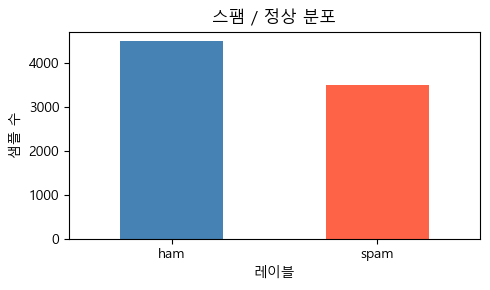

In [3]:
label_counts = df['label'].value_counts().rename({0: 'ham', 1: 'spam'})
print(label_counts)

label_counts.plot(kind='bar', color=['steelblue', 'tomato'], figsize=(5, 3))
plt.title('스팸 / 정상 분포')
plt.xlabel('레이블')
plt.ylabel('샘플 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 데이터 소스별 분포

오버피팅 방지를 위해 **두 가지 독립적인 출처**의 데이터를 사용합니다.
단일 출처 데이터는 특정 패턴에 과적합될 위험이 있습니다.

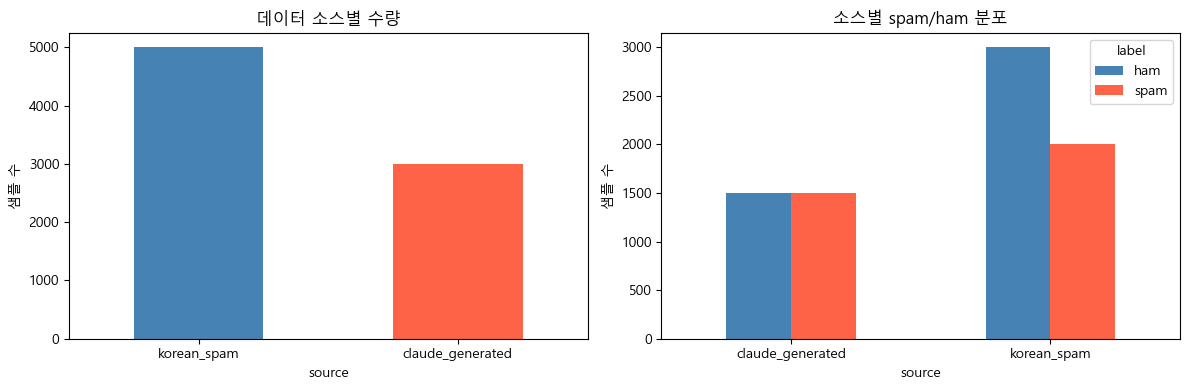

label              ham  spam
source                      
claude_generated  1500  1500
korean_spam       3000  2000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 소스별 총 수량
df['source'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('데이터 소스별 수량')
axes[0].set_ylabel('샘플 수')

# 소스 × 레이블 분포
cross = df.groupby(['source','label']).size().unstack(fill_value=0)
cross.plot(kind='bar', ax=axes[1], color=['steelblue','tomato'], rot=0)
axes[1].set_title('소스별 spam/ham 분포')
axes[1].set_ylabel('샘플 수')
axes[1].legend(title='label')

plt.tight_layout()
plt.show()
print(cross)

## 카테고리별 분포

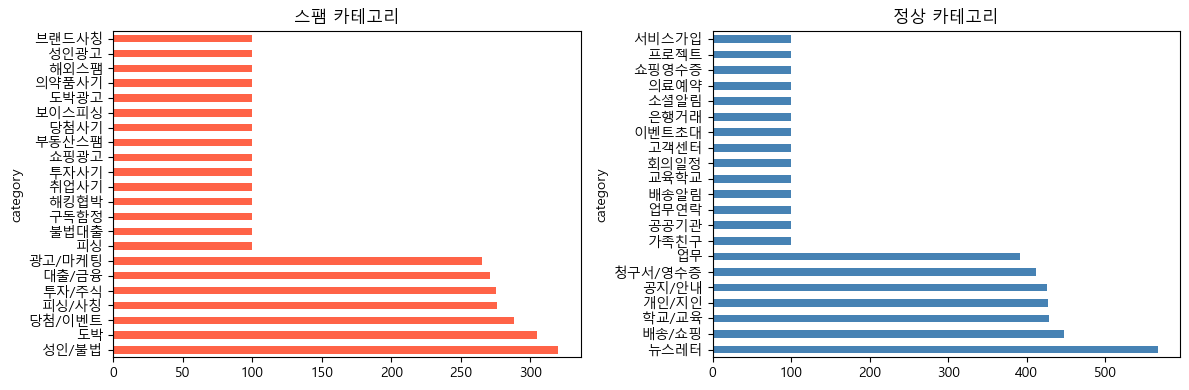

In [5]:
spam_df = df[df['label'] == 'spam']
ham_df  = df[df['label'] == 'ham']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

spam_df['category'].value_counts().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('스팸 카테고리')

ham_df['category'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('정상 카테고리')

plt.tight_layout()
plt.show()

## 텍스트 길이 분포

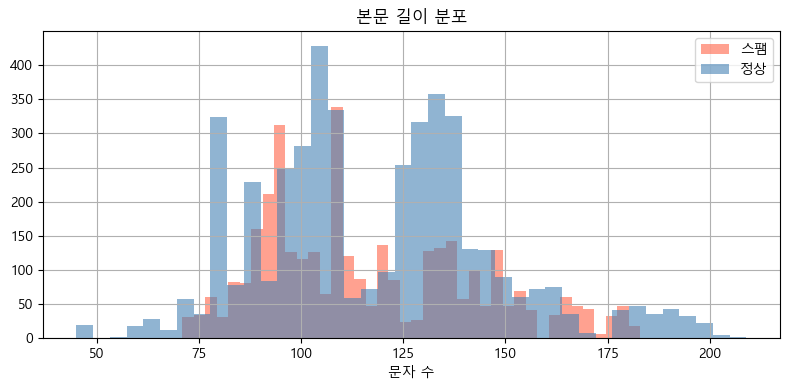

        count        mean        std   min   25%    50%    75%    max
label                                                                
ham    4500.0  118.211333  28.627437  45.0  98.0  115.0  136.0  209.0
spam   3500.0  117.013143  26.301000  71.0  95.0  110.0  136.0  183.0


In [6]:
df['body_len'] = df['body'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [('spam', 'tomato', '스팸'), ('ham', 'steelblue', '정상')]:
    df[df['label'] == label]['body_len'].hist(
        bins=40, alpha=0.6, color=color, label=name, ax=ax
    )
ax.set_title('본문 길이 분포')
ax.set_xlabel('문자 수')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label')['body_len'].describe())

## 샘플 확인

In [7]:
print('=== 스팸 샘플 ===')
sample = df[df['label'] == 'spam'].sample(1, random_state=0).iloc[0]
print(f'[카테고리] {sample["category"]}')
print(f'[제목] {sample["subject"]}')
print(f'[본문] {sample["body"][:200]}...')

print('\n=== 정상 샘플 ===')
sample = df[df['label'] == 'ham'].sample(1, random_state=0).iloc[0]
print(f'[카테고리] {sample["category"]}')
print(f'[제목] {sample["subject"]}')
print(f'[본문] {sample["body"][:200]}...')

=== 스팸 샘플 ===
[카테고리] 투자/주식
[제목] 코인 자동매매로 하루 2.9% 수익 실현
[본문] 류채원님 안녕하세요.

저희 머니플러스 리서치팀이 분석한 급등 예상 종목을 공개합니다.

📈 종목명: 에코프로
📊 목표가: 50원
⏰ 매수 타이밍: 내일 장 시작 직후

자세한 정보: http://prize-win.info/claim

※ 투자는 본인 책임입니다....

=== 정상 샘플 ===
[카테고리] 배송/쇼핑
[제목] [행운복권] 주문하신 상품이 발송되었습니다
[본문] 김민준님의 건강기능식품 주문이 확인되었습니다.

주문 정보:
주문번호: ORD78448654
결제금액: 200원
배송지: 서울시 강남구 599번지
예상 배송일: 2024년 12월 05일

문의사항은 1:1 채팅으로 연락 주세요.
럭키카지노 고객센터...
